<a href="https://colab.research.google.com/github/kheirbeqaya/Harris-Corner-Detection-Comparison-Custom-vs-OpenCV/blob/main/notebooks/Harris_Corner_Detection_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--2026-04-17 10:29:19--  https://vision.middlebury.edu/stereo/data/scenes2021/data/artroom1/im0.png
Resolving vision.middlebury.edu (vision.middlebury.edu)... 140.233.20.14
Connecting to vision.middlebury.edu (vision.middlebury.edu)|140.233.20.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2759093 (2.6M) [image/png]
Saving to: ‘Harris_img.png’

Harris_img.png      100%[===================>]   2.63M  7.65MB/s    in 0.3s    

2026-04-17 10:29:20 (7.65 MB/s) - ‘Harris_img.png’ saved [2759093/2759093]



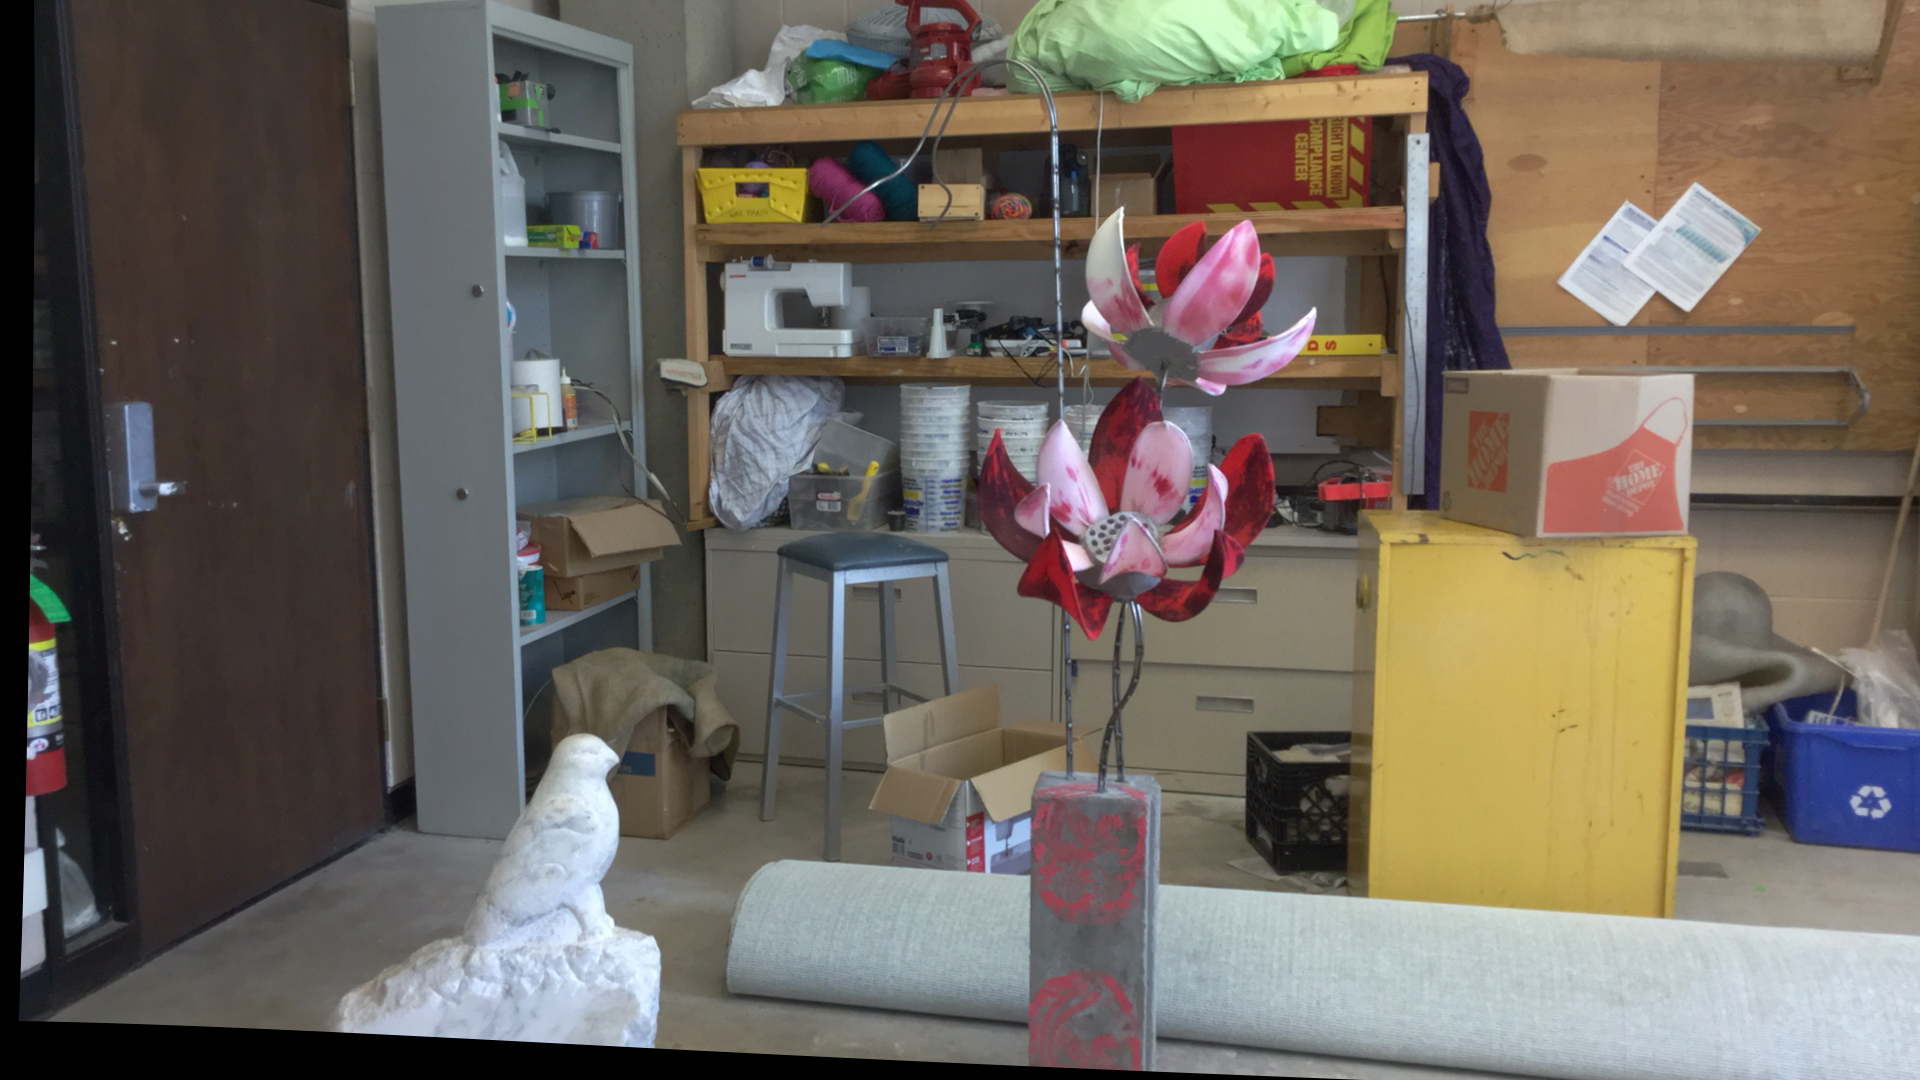

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

!wget -O Harris_img.png https://vision.middlebury.edu/stereo/data/scenes2021/data/artroom1/im0.png

image = cv2.imread("Harris_img.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cv2_imshow(image)

In [ ]:
def compute_gradients(image):
    Ix = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    return Ix, Iy


def compute_structure_tensor(Ix, Iy, window_size=3):
    Ixx = Ix**2
    Iyy = Iy**2
    Ixy = Ix * Iy

    Sxx = cv2.GaussianBlur(Ixx, (window_size, window_size), 1)
    Syy = cv2.GaussianBlur(Iyy, (window_size, window_size), 1)
    Sxy = cv2.GaussianBlur(Ixy, (window_size, window_size), 1)

    return Sxx, Syy, Sxy


def compute_harris_response(Sxx, Syy, Sxy, k=0.04):
    det = (Sxx * Syy) - (Sxy ** 2)
    trace = Sxx + Syy
    return det - k * (trace ** 2)


def non_max_suppression(R, threshold):
    corners = []
    h, w = R.shape

    for y in range(1, h-1):
        for x in range(1, w-1):
            if R[y, x] > threshold:
                if R[y, x] == np.max(R[y-1:y+2, x-1:x+2]):
                    corners.append((x, y))
    return corners


Ix, Iy = compute_gradients(gray)
Sxx, Syy, Sxy = compute_structure_tensor(Ix, Iy)
R = compute_harris_response(Sxx, Syy, Sxy)

threshold = 0.01 * R.max()
corners = non_max_suppression(R, threshold)

print("Custom corners:", len(corners))

img_custom = image.copy()
for (x, y) in corners:
    cv2.circle(img_custom, (x, y), 3, (0,0,255), -1)

Custom corners: 596


In [ ]:
gray_float = np.float32(gray)
# OpenCV Harris
harris_cv = cv2.cornerHarris(gray_float, 2, 3, 0.04)

threshold = 0.01 * harris_cv.max()

corners_cv = []

img_cv = image.copy()

h, w = harris_cv.shape

for y in range(1, h-1):
    for x in range(1, w-1):
        if harris_cv[y, x] > threshold:
            if harris_cv[y, x] == np.max(harris_cv[y-1:y+2, x-1:x+2]):
                corners_cv.append((x, y))
                cv2.circle(img_cv, (x, y), 3, (0,255,255), -1)

print("OpenCV corners:", len(corners_cv))

OpenCV corners: 476


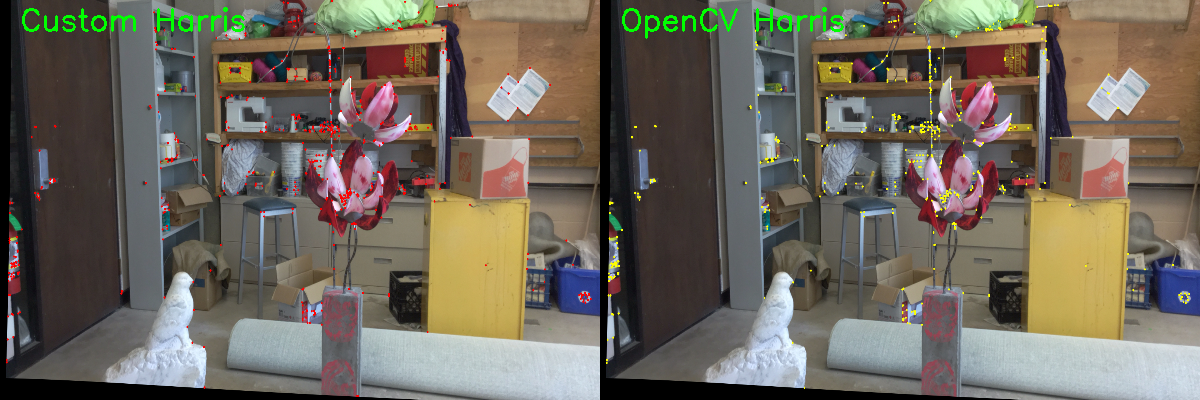

In [ ]:
img_custom_r = cv2.resize(img_custom, (600, 400))
img_cv_r = cv2.resize(img_cv, (600, 400))

cv2.putText(img_custom_r, "Custom Harris", (20,30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

cv2.putText(img_cv_r, "OpenCV Harris", (20,30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

comparison = np.hstack((img_custom_r, img_cv_r))

cv2_imshow(comparison)

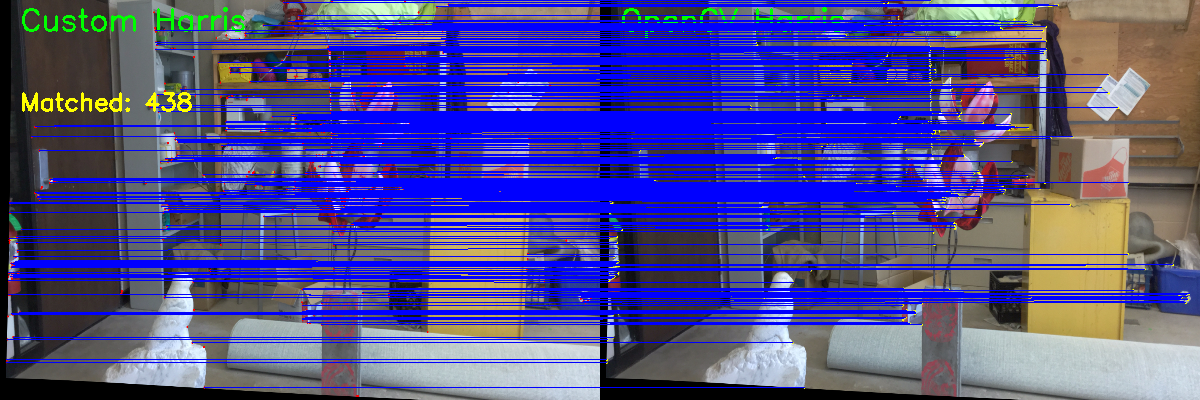

Matched points: 438


In [ ]:
new_w, new_h = 600, 400

h_orig, w_orig = gray.shape
scale_x = new_w / w_orig
scale_y = new_h / h_orig

corners_scaled = [(int(x*scale_x), int(y*scale_y)) for (x,y) in corners]
corners_cv_scaled = [(int(x*scale_x), int(y*scale_y)) for (x,y) in corners_cv]

corners_cv_set = set(corners_cv_scaled)

tolerance = 2

matched_points = []
matched_cv = set()

comparison_match = comparison.copy()

offset_x = new_w  # RIGHT image shift

for (x1, y1) in corners_scaled:

    for (x2, y2) in corners_cv_scaled:

        if (x2, y2) in matched_cv:
            continue

        if abs(x1 - x2) <= tolerance and abs(y1 - y2) <= tolerance:

            cv2.line(
                comparison_match,
                (x1, y1),
                (x2 + offset_x, y2),
                (255, 0, 0),
                1
            )

            matched_points.append((x1, y1))
            matched_cv.add((x2, y2))
            break


cv2.putText(comparison_match,
            f"Matched: {len(matched_points)}",
            (20, 110),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0,255,255),
            2)

cv2_imshow(comparison_match)

print("Matched points:", len(matched_points))